# ViT-Base Alzheimer's Detection — Multi-Slice & Out-of-Domain Evaluation

This notebook evaluates `dhritic99/vit-base-brain-alzheimer-detection` across **all five week1 datasets**. It is a fine-tuned image classifier, not a generative VLM, so outputs are **class probability distributions** across 4 dementia severity levels.

**What is this model?**  
A Google ViT-base-patch16-224 (pretrained on ImageNet-21k) fine-tuned for Alzheimer's severity classification. Trained on axial brain MRI slices; reaches 95.6% validation accuracy.

**Architecture:**
- Base: `google/vit-base-patch16-224-in21k`
- Task: `image-classification` (4 classes)
- Input: 224×224 RGB, normalized with mean=0.5, std=0.5
- Parameters: ~86M

**Classification classes** — the model card does not document `id2label`. Based on the standard Kaggle Alzheimer's MRI Dataset (the most common source for this task), the 4 labels in alphabetical order are:

| Label ID | Class name | Clinical meaning |
|---|---|---|
| 0 | `MildDemented` | Mild cognitive impairment, noticeable memory loss |
| 1 | `ModerateDemented` | Significant memory loss, needs assistance with daily tasks |
| 2 | `NonDemented` | No detectable cognitive impairment |
| 3 | `VeryMildDemented` | Earliest detectable stage, slight memory lapses |

> **Note:** Label order is inferred from alphabetical Kaggle dataset class ordering — the author did not publish `id2label`. Results should be interpreted with this caveat in mind.

**Model ID:** `dhritic99/vit-base-brain-alzheimer-detection` (open, no HF token required)  
**Environment:** Main `ai-healthcare` kernel (standard `AutoModelForImageClassification` API).

## Evaluation Plan

| Dataset | Modality | In-domain? | Evaluation strategy |
|---|---|---|---|
| **OASIS-1** | Brain MRI T1 (Analyze 7.5) | **Yes** | Sample every 15th axial slice across the full volume → per-slice class distribution + aggregate |
| IQ-OTH/NCCD | Chest CT (JPEG) | No — CT, chest | Out-of-domain: all 3 class images |
| Spinal CT | Spectral CT spine (DICOM) | No — CT, spine | Out-of-domain: 1 slice |
| Quilt1M | H&E histopathology (JPEG) | No — microscopy | Out-of-domain: 4 samples (one per source) |
| PKG HSI-GB | Hyperspectral brain tumor (ENVI) | No — microscopy | Out-of-domain: pseudo-RGB of P1 ROI |

**Why out-of-domain testing matters:** A classifier fine-tuned on axial brain MRI should assign high entropy (uniform probability) to images from completely different modalities. If it confidently misclassifies them, it reveals calibration issues. This is clinically relevant: a deployed model may receive unexpected input types.

In [1]:
import json
import time
import warnings
import logging

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
logging.getLogger("transformers").setLevel(logging.ERROR)

In [2]:
from pathlib import Path

import nibabel as nib
import numpy as np
import pydicom
import spectral.io.envi as envi
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from transformers import AutoModelForImageClassification, AutoImageProcessor

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


## Model Loading

Standard HuggingFace `AutoModelForImageClassification` + `AutoImageProcessor`.  
The `ViTImageProcessor` handles resize to 224×224 and normalization (mean=0.5, std=0.5).

In [3]:
MODEL_ID = "dhritic99/vit-base-brain-alzheimer-detection"

_t0_load = time.perf_counter()
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModelForImageClassification.from_pretrained(MODEL_ID)
model = model.to(device)
model.eval()
model_load_s = round(time.perf_counter() - _t0_load, 2)

# The model card does not document id2label.
# Based on the standard Kaggle Alzheimer's MRI Dataset (alphabetical class ordering):
CLASS_NAMES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
NUM_CLASSES = len(CLASS_NAMES)

# Colour palette for bar charts (consistent across the notebook)
CLASS_COLORS = ["#e74c3c", "#c0392b", "#2ecc71", "#f39c12"]

print(f"Model loaded: {model.__class__.__name__}")
print(f"Num labels : {model.config.num_labels}")
print(f"Image size : {processor.size}")
print(f"Classes    : {CLASS_NAMES}")
print(f"Load time  : {model_load_s}s")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Model loaded: ViTForImageClassification
Num labels : 4
Image size : SizeDict(height=224, width=224, longest_edge=None, shortest_edge=None, max_height=None, max_width=None)
Classes    : ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
Load time  : 1.15s


## Image Loaders & Classification Helper

Same modality-specific loaders as the other week2 notebooks.  
`classify()` returns a length-4 numpy array of softmax probabilities (one per class).

In [4]:
def load_image(path: Path) -> Image.Image:
    return Image.open(path).convert("RGB")


def load_dicom(path: Path) -> Image.Image:
    ds = pydicom.dcmread(str(path))
    raw = ds.pixel_array.astype(float)
    slope = float(getattr(ds, "RescaleSlope", 1))
    intercept = float(getattr(ds, "RescaleIntercept", 0))
    hu = raw * slope + intercept
    wl, ww = 40.0, 400.0
    lo, hi = wl - ww / 2, wl + ww / 2
    windowed = np.clip((hu - lo) / (hi - lo) * 255.0, 0, 255).astype(np.uint8)
    return Image.fromarray(windowed).convert("RGB")


def load_hsi(hdr_path: Path) -> Image.Image:
    img = envi.open(str(hdr_path))
    wl = np.array([float(w) for w in img.metadata["wavelength"]])
    br, bg, bb = [int(np.argmin(np.abs(wl - t))) for t in (650, 550, 450)]
    def norm(band_idx):
        arr = np.squeeze(img.read_band(band_idx))
        lo, hi = arr.min(), arr.max()
        return ((arr - lo) / (hi - lo + 1e-9) * 255).astype(np.uint8)
    return Image.fromarray(np.stack([norm(br), norm(bg), norm(bb)], axis=2))


def classify(pil_img: Image.Image) -> np.ndarray:
    """
    Run ViT classifier on a PIL image.
    Returns a (4,) float32 array of softmax probabilities in CLASS_NAMES order.
    """
    inputs = processor(images=pil_img, return_tensors="pt").to(device)
    with torch.inference_mode():
        logits = model(**inputs).logits          # (1, 4)
    probs = F.softmax(logits, dim=-1).squeeze().cpu().float().numpy()
    return probs  # shape (4,)


def plot_bar(probs: np.ndarray, title: str, ax=None) -> None:
    """Horizontal bar chart of class probabilities."""
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(5, 2.2))
    bars = ax.barh(CLASS_NAMES, probs, color=CLASS_COLORS)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Probability")
    ax.set_title(title, fontsize=8)
    for bar, p in zip(bars, probs):
        ax.text(min(p + 0.02, 0.95), bar.get_y() + bar.get_height() / 2,
                f"{p:.2%}", va="center", fontsize=7)
    if own_fig:
        plt.tight_layout()
        plt.show()

## Dataset 1 (In-Domain): OASIS-1 — Brain MRI T1

**Background:** OASIS-1 contains T1-weighted MPRAGE MRI from 416 subjects (18–96 years), including early-stage Alzheimer's disease. Subject `OAS1_0001_MR1` is a 74-year-old female with CDR=0 (non-demented, ground truth).

**Volume used:** `T88_111/OAS1_0001_MR1_mpr_n4_anon_111_t88_gfc.img` — T88 atlas-registered, gain-field corrected, in standard MNI space.

**Multi-slice strategy:** Sample every 15th axial slice across the full volume depth. For each slice:
- Display the slice image
- Show the full 4-class probability bar chart

After all slices, plot the **per-class probability trajectory** across slice positions to see whether predictions are consistent or vary with anatomy (ventricles, cortex, etc.).

**Expected behaviour:** Since this subject is `NonDemented` (CDR=0), the model should predominantly predict `NonDemented`. Slices with more cortex visible may be classified with higher confidence than slices through skull/neck.

In [5]:
BASE_DATA_DIR = Path("../week1/data")

OASIS_VOL_PATH = (
    BASE_DATA_DIR
    / "Oasis1/OAS1_0001_MR1/PROCESSED/MPRAGE/T88_111"
    / "OAS1_0001_MR1_mpr_n4_anon_111_t88_gfc.img"
)

# Load volume — np.squeeze collapses any dummy time dimension (OASIS is stored as 4D x,y,z,1)
vol = np.squeeze(nib.load(str(OASIS_VOL_PATH)).get_fdata())  # → 3D (x, y, z)
n_slices = vol.shape[2]
print(f"Volume shape (after squeeze): {vol.shape}")
print(f"Axial slices: {n_slices}")

STRIDE = 15
slice_indices = list(range(0, n_slices, STRIDE))
print(f"Sampling every {STRIDE}th slice → {len(slice_indices)} slices: {slice_indices}")

Volume shape (after squeeze): (176, 208, 176)
Axial slices: 176
Sampling every 15th slice → 12 slices: [0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165]


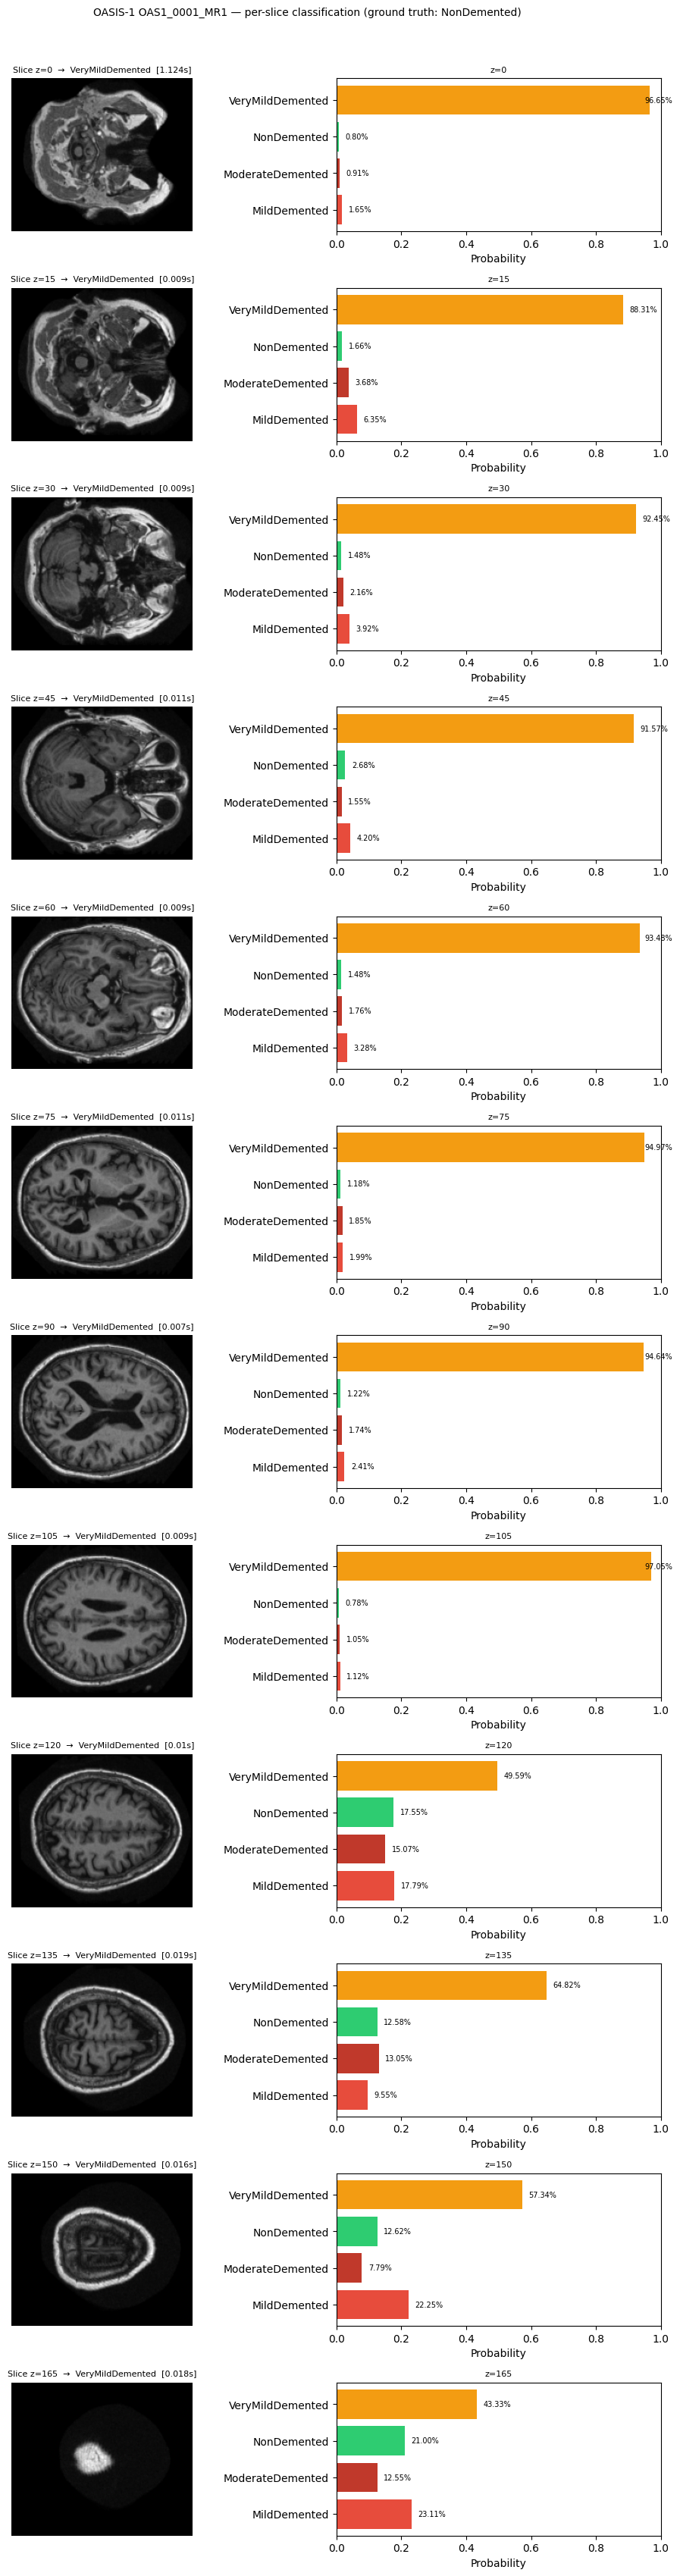


Classified 12 slices in 2.13s (mean 0.104s/slice)


In [6]:
def vol_slice_to_pil(vol: np.ndarray, z: int) -> Image.Image:
    """Extract axial slice z from a 3D volume and return a normalised RGB PIL image."""
    slc = vol[:, :, z]
    lo, hi = slc.min(), slc.max()
    arr = ((slc - lo) / (hi - lo + 1e-9) * 255).astype(np.uint8)
    return Image.fromarray(arr).convert("RGB")


# Classify each sampled slice
oasis_probs = []
oasis_times = []   # per-slice inference time
_t_oasis_start = time.perf_counter()

n_cols = 4
n_rows = len(slice_indices)

fig, axes = plt.subplots(n_rows, 2, figsize=(10, 2.8 * n_rows))
if n_rows == 1:
    axes = [axes]

for row, z in enumerate(slice_indices):
    pil_img = vol_slice_to_pil(vol, z)
    _t0 = time.perf_counter()
    probs = classify(pil_img)
    _slice_t = round(time.perf_counter() - _t0, 3)
    oasis_probs.append(probs)
    oasis_times.append(_slice_t)
    pred_label = CLASS_NAMES[int(np.argmax(probs))]

    ax_img, ax_bar = axes[row]

    ax_img.imshow(pil_img, cmap="gray")
    ax_img.axis("off")
    ax_img.set_title(f"Slice z={z}  →  {pred_label}  [{_slice_t}s]", fontsize=8)

    plot_bar(probs, title=f"z={z}", ax=ax_bar)

plt.suptitle("OASIS-1 OAS1_0001_MR1 — per-slice classification (ground truth: NonDemented)",
             fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

oasis_probs = np.array(oasis_probs)   # (n_slices, 4)
oasis_total_s = round(time.perf_counter() - _t_oasis_start, 2)
print(f"\nClassified {len(slice_indices)} slices in {oasis_total_s}s (mean {round(sum(oasis_times)/len(oasis_times),3)}s/slice)")

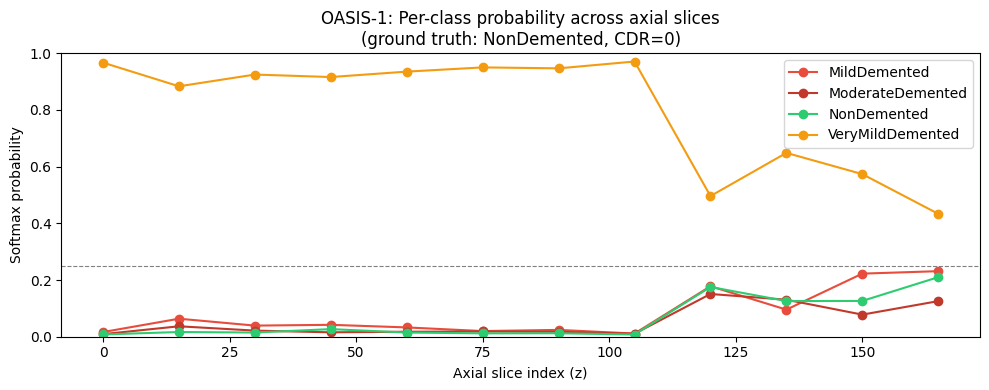

Mean probability per class across all sampled slices:
  MildDemented        : 0.081
  ModerateDemented    : 0.053
  NonDemented         : 0.063
  VeryMildDemented    : 0.804 ← highest

Modal prediction per slice: Counter({'VeryMildDemented': 12})


In [7]:
# Probability trajectory across slice positions
fig, ax = plt.subplots(figsize=(10, 4))
for i, (cls, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    ax.plot(slice_indices, oasis_probs[:, i], marker="o", label=cls, color=color)
ax.set_xlabel("Axial slice index (z)")
ax.set_ylabel("Softmax probability")
ax.set_ylim(0, 1)
ax.set_title("OASIS-1: Per-class probability across axial slices\n(ground truth: NonDemented, CDR=0)")
ax.legend(loc="upper right")
ax.axhline(0.25, color="gray", linestyle="--", linewidth=0.8, label="Uniform (0.25)")
plt.tight_layout()
plt.show()

# Summary statistics
print("Mean probability per class across all sampled slices:")
for cls, mean_p in zip(CLASS_NAMES, oasis_probs.mean(axis=0)):
    marker = " ← highest" if mean_p == oasis_probs.mean(axis=0).max() else ""
    print(f"  {cls:20s}: {mean_p:.3f}{marker}")

modal_predictions = [CLASS_NAMES[int(np.argmax(p))] for p in oasis_probs]
from collections import Counter
print(f"\nModal prediction per slice: {Counter(modal_predictions)}")

## Dataset 2–5 (Out-of-Domain): IQ-OTH, Spinal CT, Quilt1M, PKG HSI-GB

These datasets are completely outside the model's training distribution (chest/spinal CT, histopathology, hyperspectral microscopy). A well-calibrated model should produce **near-uniform probability distributions** (each class ≈ 0.25) — high confidence on any single class indicates overconfident out-of-distribution behaviour.

**Samples:**

| Sample | Dataset | Modality |
|---|---|---|
| Benign_case_1 | IQ-OTH/NCCD | Chest CT |
| Malignant_case_1 | IQ-OTH/NCCD | Chest CT |
| Normal_case_1 | IQ-OTH/NCCD | Chest CT |
| Myel_001 slice | Spinal CT DICOM | Spectral CT spine |
| Quilt1M pubmed | Quilt1M | H&E histopathology |
| Quilt1M quilt | Quilt1M | H&E histopathology |
| Quilt1M openpath | Quilt1M | H&E histopathology |
| Quilt1M laion | Quilt1M | H&E histopathology |
| PKG P1 ROI_01 | PKG HSI-GB | Hyperspectral brain tumor |

  [0.013s] IQ-OTH Benign


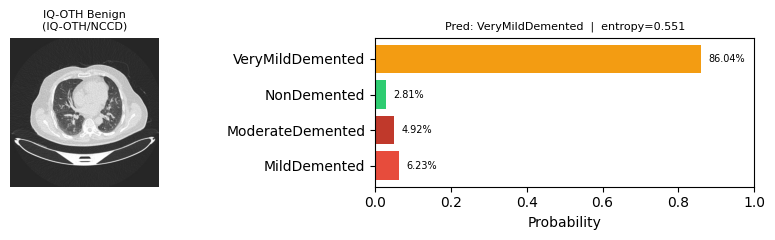

  [0.01s] IQ-OTH Malignant


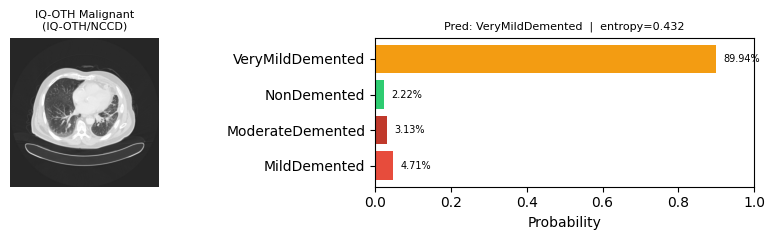

  [0.011s] IQ-OTH Normal


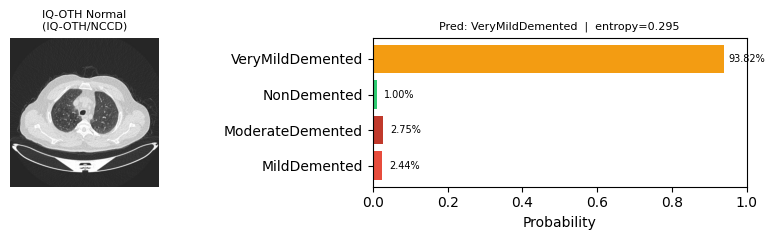

  [0.01s] Spinal DICOM Myel001


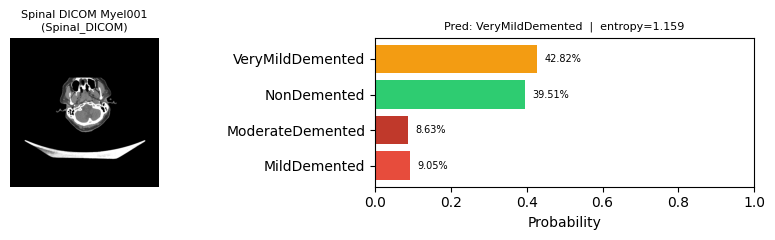

  [0.008s] Quilt1M pubmed


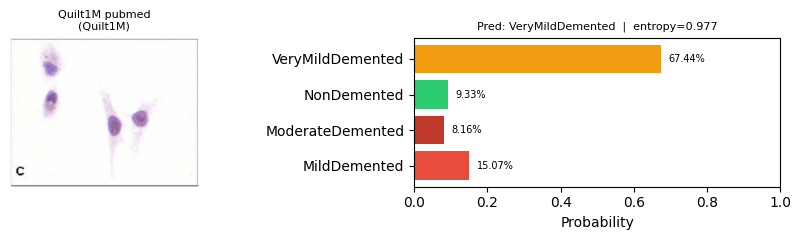

  [0.031s] Quilt1M quilt


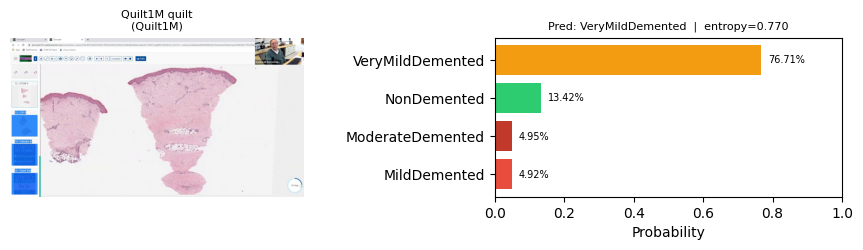

  [0.097s] Quilt1M openpath


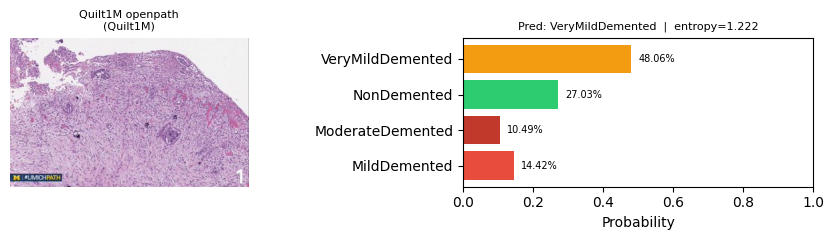

  [0.019s] Quilt1M laion


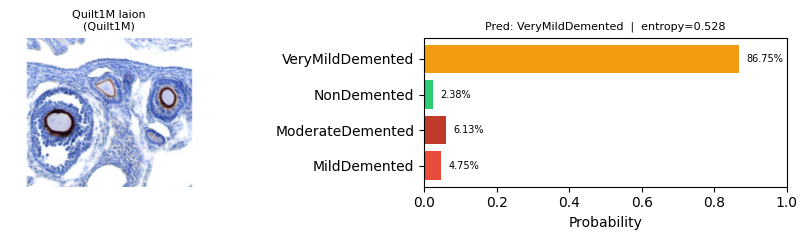

  [0.021s] PKG HSI GB P1


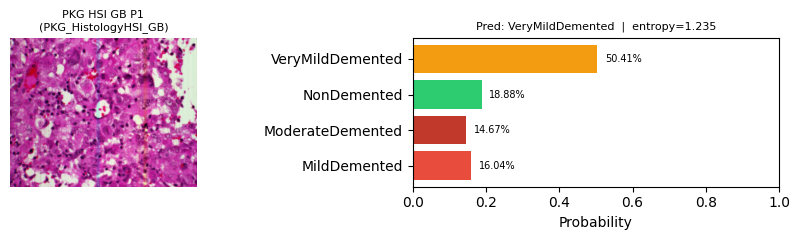


OOD inference time: 1.41s


In [8]:
OOD_SAMPLES = [
    {
        "name": "IQ-OTH Benign",
        "dataset": "IQ-OTH/NCCD",
        "path": BASE_DATA_DIR / "IQ-OTH_NCCD/Benign/Benign_case_1.jpg",
        "loader": "image",
    },
    {
        "name": "IQ-OTH Malignant",
        "dataset": "IQ-OTH/NCCD",
        "path": BASE_DATA_DIR / "IQ-OTH_NCCD/Malignant/Malignant_case_1.jpg",
        "loader": "image",
    },
    {
        "name": "IQ-OTH Normal",
        "dataset": "IQ-OTH/NCCD",
        "path": BASE_DATA_DIR / "IQ-OTH_NCCD/Normal/Normal_case_1.jpg",
        "loader": "image",
    },
    {
        "name": "Spinal DICOM Myel001",
        "dataset": "Spinal_DICOM",
        "path": BASE_DATA_DIR / "Spinal_DICOM/Myel_001/MonoE_80keVHU/1-0001.dcm",
        "loader": "dicom",
    },
    {
        "name": "Quilt1M pubmed",
        "dataset": "Quilt1M",
        "path": BASE_DATA_DIR / "Quilt1M_pubmed/c901a42b-0ab9-45d9-809d-dd646effcf9c_1.jpg",
        "loader": "image",
    },
    {
        "name": "Quilt1M quilt",
        "dataset": "Quilt1M",
        "path": BASE_DATA_DIR / "Quilt1M_quilt/dTr3MNl1FxE_image_c54e9a8d-9348-456a-9645-3b8921eb0b79.jpg",
        "loader": "image",
    },
    {
        "name": "Quilt1M openpath",
        "dataset": "Quilt1M",
        "path": BASE_DATA_DIR / "Quilt1M_openpath/994701482116173824_0.jpg",
        "loader": "image",
    },
    {
        "name": "Quilt1M laion",
        "dataset": "Quilt1M",
        "path": BASE_DATA_DIR / "Quilt1M_laion/00004000040081.jpg",
        "loader": "image",
    },
    {
        "name": "PKG HSI GB P1",
        "dataset": "PKG_HistologyHSI_GB",
        "path": BASE_DATA_DIR / "PKG_HistologyHSI_GB/P1/ROI_01_C01_T/raw.hdr",
        "loader": "hsi",
    },
]

LOADERS = {"image": load_image, "dicom": load_dicom, "hsi": load_hsi}

ood_results = []
_t_ood_start = time.perf_counter()

for sample in OOD_SAMPLES:
    pil_img = LOADERS[sample["loader"]](sample["path"])
    _t0 = time.perf_counter()
    probs = classify(pil_img)
    sample_time_s = round(time.perf_counter() - _t0, 3)
    pred = CLASS_NAMES[int(np.argmax(probs))]
    entropy = -np.sum(probs * np.log(probs + 1e-9))   # bits; max = ln(4) ≈ 1.386
    print(f"  [{sample_time_s}s] {sample['name']}")
    ood_results.append({**sample, "probs": probs, "pred": pred, "entropy": entropy, "time_s": sample_time_s})

    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(9, 2.5))
    ax_img.imshow(pil_img)
    ax_img.axis("off")
    ax_img.set_title(f"{sample['name']}\n({sample['dataset']})", fontsize=8)
    plot_bar(probs, title=f"Pred: {pred}  |  entropy={entropy:.3f}", ax=ax_bar)
    plt.tight_layout()
    plt.show()
ood_total_s = round(time.perf_counter() - _t_ood_start, 2)
print(f"\nOOD inference time: {ood_total_s}s")


## Summary: In-Domain vs Out-of-Domain Comparison

Entropy = −Σ p·log(p). Maximum entropy (most uncertain) = ln(4) ≈ 1.386 (uniform distribution). A well-calibrated model should have **high entropy on OOD inputs** and **low entropy on in-domain inputs** with the correct class.

Alzheimer ViT — Full Evaluation Summary
(Max entropy = 1.386, i.e. completely uncertain)
                       name  in_domain             pred  entropy  entropy_pct_max  time_s  MildDemented  ModerateDemented  NonDemented  VeryMildDemented
OASIS-1 (mean of 12 slices)       True VeryMildDemented 0.587438             42.4     NaN      0.081349          0.052637     0.062513          0.803500
              IQ-OTH Benign      False VeryMildDemented 0.550948             39.7   0.013      0.062337          0.049182     0.028113          0.860367
           IQ-OTH Malignant      False VeryMildDemented 0.432229             31.2   0.010      0.047126          0.031318     0.022162          0.899394
              IQ-OTH Normal      False VeryMildDemented 0.295091             21.3   0.011      0.024360          0.027488     0.009969          0.938183
       Spinal DICOM Myel001      False VeryMildDemented 1.158866             83.6   0.010      0.090481          0.086271     0.395093          0.

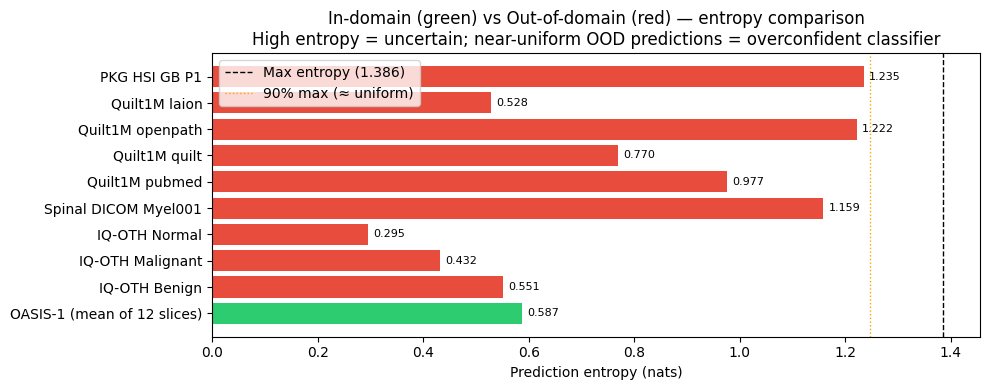


Results + timings saved to vit_alzheimer_results.json
  Model load : 1.15s
  OASIS total: 2.13s  (mean 0.104s/slice)
  OOD total  : 1.41s


In [9]:
import pandas as pd

MAX_ENTROPY = np.log(4)  # ≈ 1.386

# ── OASIS-1 summary row (aggregate) ──────────────────────────────────────────
oasis_mean_probs = oasis_probs.mean(axis=0)
oasis_entropy_per_slice = -np.sum(oasis_probs * np.log(oasis_probs + 1e-9), axis=1)
oasis_row = {
    "name": f"OASIS-1 (mean of {len(slice_indices)} slices)",
    "dataset": "OASIS-1",
    "in_domain": True,
    "pred": CLASS_NAMES[int(np.argmax(oasis_mean_probs))],
    "entropy": float(oasis_entropy_per_slice.mean()),
    "mean_time_s": round(float(np.mean(oasis_times)), 3),
    "total_time_s": float(oasis_total_s),
    **{cls: float(oasis_mean_probs[i]) for i, cls in enumerate(CLASS_NAMES)},
}

# ── OOD rows ─────────────────────────────────────────────────────────────────
ood_rows = []
for r in ood_results:
    ood_rows.append({
        "name": r["name"],
        "dataset": r["dataset"],
        "in_domain": False,
        "pred": r["pred"],
        "entropy": float(r["entropy"]),
        "time_s": r.get("time_s", None),
        **{cls: float(r["probs"][i]) for i, cls in enumerate(CLASS_NAMES)},
    })

df = pd.DataFrame([oasis_row] + ood_rows)
df["entropy_pct_max"] = (df["entropy"] / MAX_ENTROPY * 100).round(1)

print("Alzheimer ViT — Full Evaluation Summary")
print(f"(Max entropy = {MAX_ENTROPY:.3f}, i.e. completely uncertain)")
print("=" * 100)

cols = ["name", "in_domain", "pred", "entropy", "entropy_pct_max", "time_s"] + CLASS_NAMES
print(df[cols].to_string(index=False))

# ── Entropy comparison bar chart ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#2ecc71" if row["in_domain"] else "#e74c3c" for _, row in df.iterrows()]
bars = ax.barh(df["name"], df["entropy"], color=colors)
ax.axvline(MAX_ENTROPY, color="black", linestyle="--", linewidth=1, label=f"Max entropy ({MAX_ENTROPY:.3f})")
ax.axvline(MAX_ENTROPY * 0.9, color="orange", linestyle=":", linewidth=1, label="90% max (≈ uniform)")
ax.set_xlabel("Prediction entropy (nats)")
ax.set_title("In-domain (green) vs Out-of-domain (red) — entropy comparison\nHigh entropy = uncertain; near-uniform OOD predictions = overconfident classifier")
ax.legend()
for bar, val in zip(bars, df["entropy"]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()
VIT_RESULTS_PATH = Path("vit_alzheimer_results.json")
timing_meta = {
    "model_load_s": model_load_s,
    "oasis_total_s": oasis_total_s,
    "oasis_mean_per_slice_s": round(float(np.mean(oasis_times)), 3),
    "ood_total_s": ood_total_s,
}
with open(VIT_RESULTS_PATH, "w") as _f:
    json.dump({
        **timing_meta,
        "results": df[cols].to_dict(orient="records"),
    }, _f, indent=2)
print(f"\nResults + timings saved to {VIT_RESULTS_PATH}")
print(f"  Model load : {model_load_s}s")
print(f"  OASIS total: {oasis_total_s}s  (mean {timing_meta['oasis_mean_per_slice_s']}s/slice)")
print(f"  OOD total  : {ood_total_s}s")
